In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

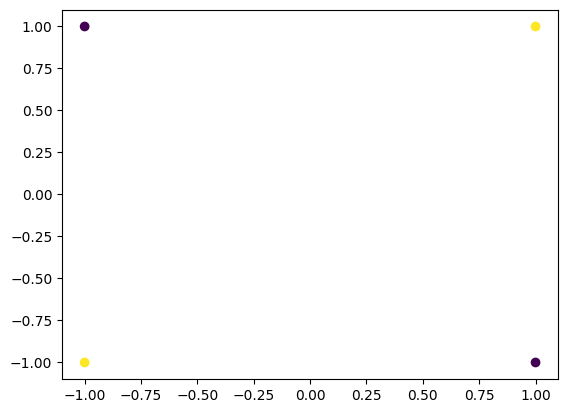

In [6]:
data = np.array([
    (1, 1, 1),
    (-1, 1, -1),
    (1, -1, -1),
    (-1, -1, 1),
])

_ = plt.scatter(data[:, 0], data[:, 1], c=data[:, 2])

### Gradient of a Neuron with Sigmoid Activation

Given:
$f(z) = \frac{1}{1 + e^{-z}}$ where $z = w_1x_1 + w_2x_2 + b$

#### 1. Derivation of $\frac{\partial f}{\partial w_1}$
Using the Chain Rule:
$$
\frac{\partial f}{\partial w_1} = \frac{\partial f}{\partial z} \cdot \frac{\partial z}{\partial w_1}
$$

* **Step A:** The derivative of the sigmoid function is $\frac{df}{dz} = f(z)(1 - f(z))$.
* **Step B:** The partial derivative of $z$ with respect to $w_1$ is $\frac{\partial z}{\partial w_1} = x_1$.
* **Result:** $\frac{\partial f}{\partial w_1} = f(z)(1 - f(z))x_1$

#### 2. Bound of the Gradient
The term $f(z)(1 - f(z))$ is a parabola with a maximum value of **0.25** (occurring at $f(z) = 0.5$).
Therefore:
$$
\left| \frac{\partial f}{\partial w_1} \right| \leq 0.25 |x_1|
$$

#### 3. Vanishing Gradient
As $|z| \to \infty$, $f(z)$ approaches either $0$ or $1$. In both cases, the term $f(z)(1 - f(z)) \to 0$.
* **Result:** The gradient vanishes for large $|z|$.

#### 4. Independence of Bias ($b$)
Since $z$ depends on $b$, and $f(z)$ depends on $z$, the gradient $\frac{\partial f}{\partial w_1}$ is **dependent** on the bias.

### Regions Divided by a Perceptron Decision Boundary

Given:
* Space: $\mathbb{R}^7$
* Decision boundary: $w^Tx = 0$

#### Derivation
* The equation $w^Tx = 0$ defines a single **hyperplane** in the $n$-dimensional space $\mathbb{R}^n$ (in this case, $n=7$).
* A single hyperplane universally divides the entire space into exactly **two** distinct half-spaces (connected regions), regardless of the dimensionality $n$.
* **Region 1:** Points where $w^Tx \geq 0$ (Output $+1$)
* **Region 2:** Points where $w^Tx < 0$ (Output $-1$)

### Simple 2-layer neural network

In [17]:
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU(),
    nn.Linear(1, 1),
    nn.ReLU(),
)

for i in [0, 2]:
  _ = nn.init.constant_(model[i].weight, 1.)
  _ = nn.init.constant_(model[i].bias, 0.)

for name, param in model.named_parameters():
  print(name, param, '\n')

0.weight Parameter containing:
tensor([[1.]], requires_grad=True) 

0.bias Parameter containing:
tensor([0.], requires_grad=True) 

2.weight Parameter containing:
tensor([[1.]], requires_grad=True) 

2.bias Parameter containing:
tensor([0.], requires_grad=True) 



In [18]:
model(torch.tensor([0.]))
model(torch.tensor([2.]))

tensor([0.], grad_fn=<ReluBackward0>)

tensor([2.], grad_fn=<ReluBackward0>)

## 80 layer NN

In [21]:
layers = [nn.Linear(5, 10, bias=False), nn.ReLU()]
for _ in range(79):
  layers.extend([nn.Linear(10, 10, bias=False), nn.ReLU()])
layers.extend([nn.Linear(10, 1, bias=False), nn.Sigmoid()])

model = nn.Sequential(*layers)

for param in model.parameters():
  _ = nn.init.constant_(param, 1.0)

x = torch.tensor([-6.0, 2.0, 1.0, -3.0, 2.0])
model(x)

tensor([0.5000], grad_fn=<SigmoidBackward0>)

### Why Huber Loss?

**Huber Loss** is the best choice for regression tasks with outliers because it behaves as a hybrid:
1.  **Robust to Outliers:** For large errors, it applies a *linear* penalty (like Mean Absolute Error), preventing extreme values from drastically skewing the model.
2.  **Smooth Convergence:** For small errors, it applies a *quadratic* penalty (like Mean Squared Error), ensuring smooth gradient descent near the minimum.

*(Note: MSE and SSE square the errors, making them highly sensitive to outliers. Binary Cross Entropy is for classification, not regression.)*